In [16]:
# extract YouTube audio.
from pathlib import Path
audiofile = Path('/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/02_KSC/spaceX_explosion_movie/syncedsound2.mp3')
import librosa

# Load MP3 at its original sample rate
y, sr = librosa.load(audiofile, sr=None)

print(sr)          # sample rate (Hz)
print(len(y))      # number of samples
print(len(y)/sr)   # duration (s)

44100
7357105
166.82777777777778


In [17]:
import numpy as np
from obspy import Trace, Stream, UTCDateTime

# Convert to float32 for ObsPy
data = np.asarray(y, dtype=np.float32)

tr = Trace(data=data)
tr.stats.sampling_rate = sr
tr.stats.network = "YT"
tr.stats.station = "SYNC"
tr.stats.location = ""
tr.stats.channel = "AUD"
tr.stats.starttime = UTCDateTime("2016-09-01T13:07:10.000")  # adjust if needed

st_audio = Stream([tr])

print(st_audio)
print(st_audio[0].stats)

1 Trace(s) in Stream:
YT.SYNC..AUD | 2016-09-01T13:07:10.000000Z - 2016-09-01T13:09:56.827755Z | 44100.0 Hz, 7357105 samples
         network: YT
         station: SYNC
        location: 
         channel: AUD
       starttime: 2016-09-01T13:07:10.000000Z
         endtime: 2016-09-01T13:09:56.827755Z
   sampling_rate: 44100.0
           delta: 2.2675736961451248e-05
            npts: 7357105
           calib: 1.0


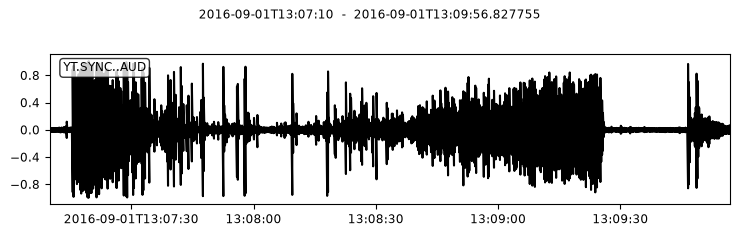

In [18]:
st_audio.plot();

/var/folders/sz/wyydztsx6q7gbrq8b1pl4fl00000gn/T/ipykernel_40614/316927270.py:24: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 10000)


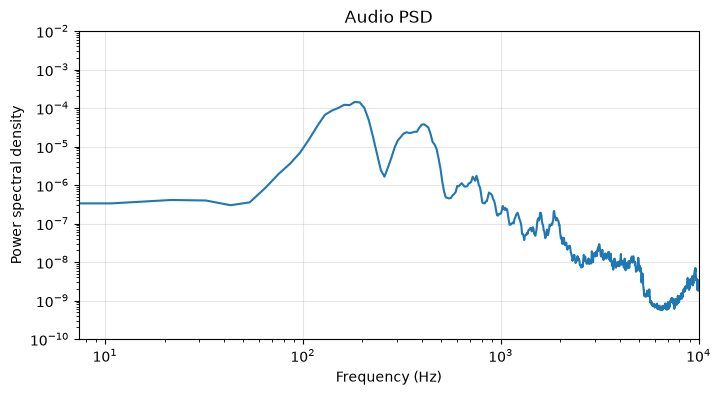

In [19]:
from scipy.signal import welch
import matplotlib.pyplot as plt

tr = st_audio[0].copy()
tr.detrend("demean")
tr.taper(max_percentage=0.05)

fs = tr.stats.sampling_rate
x = tr.data.astype(float)

f, Pxx = welch(
    x,
    fs=fs,
    nperseg=min(4096, len(x)),
    noverlap=None,
    scaling="density"
)

plt.figure(figsize=(8, 4))
plt.loglog(f, Pxx)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
plt.title("Audio PSD")
plt.xlim(0, 10000)
plt.ylim(1e-10, 1e-2)
plt.grid(True, alpha=0.3)
plt.show()

/Users/thompsong/miniforge3/envs/flovopy_asl/lib/python3.12/site-packages/obspy/imaging/spectrogram.py:144: RuntimeWarning: divide by zero encountered in log10
  specgram = 10 * np.log10(specgram[1:, :])
/Users/thompsong/miniforge3/envs/flovopy_asl/lib/python3.12/site-packages/obspy/imaging/spectrogram.py:155: RuntimeWarning: invalid value encountered in scalar add
  vmax = specgram.min() + vmax * _range


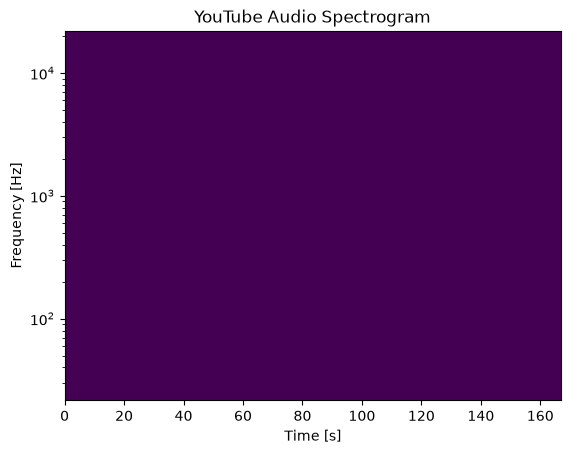

[None]

In [20]:
st_audio.spectrogram(log=True, title="YouTube Audio Spectrogram", cmap="viridis", dbscale=True, show=True)

/var/folders/sz/wyydztsx6q7gbrq8b1pl4fl00000gn/T/ipykernel_40614/2801140317.py:23: RuntimeWarning: divide by zero encountered in log10
  10*np.log10(S),


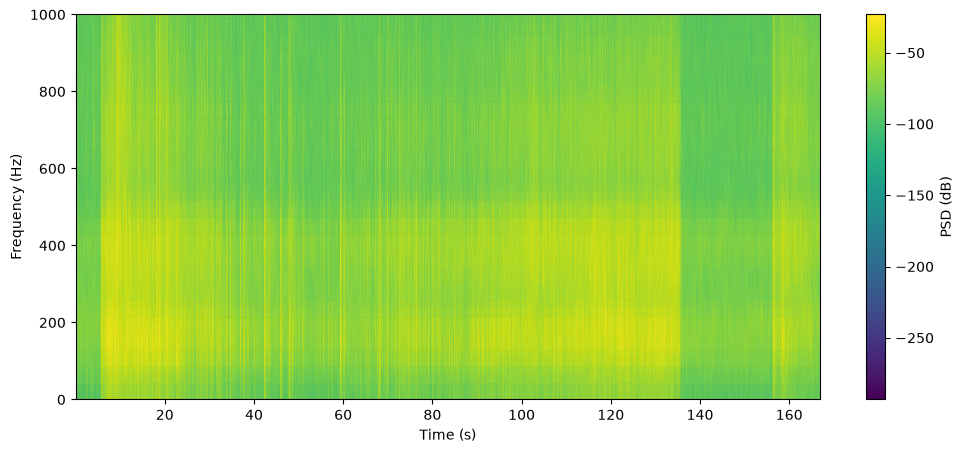

In [21]:
from scipy.signal import spectrogram
import matplotlib.pyplot as plt
import numpy as np

tr = st_audio[0].copy()
x = tr.data.astype(float)
fs = tr.stats.sampling_rate

f, t, S = spectrogram(
    x,
    fs=fs,
    window="hann",
    nperseg=1024,
    noverlap=768,
    scaling="density",
    mode="psd"
)

plt.figure(figsize=(12,5))
plt.pcolormesh(
    t,
    f,
    10*np.log10(S),
    shading="gouraud"
)
plt.ylim(0,1000)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="PSD (dB)")
plt.show()

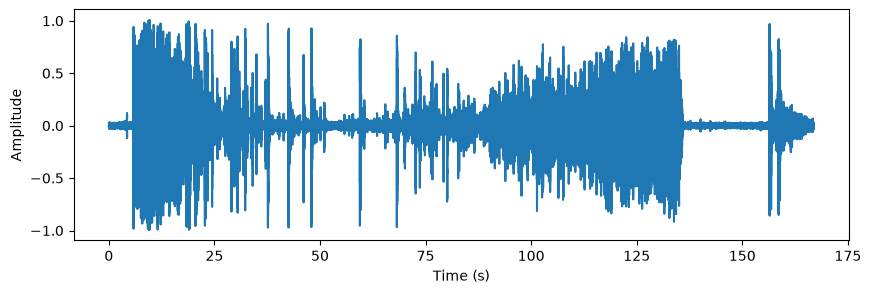

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
plt.plot(st_audio[0].times(), st_audio[0].data)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

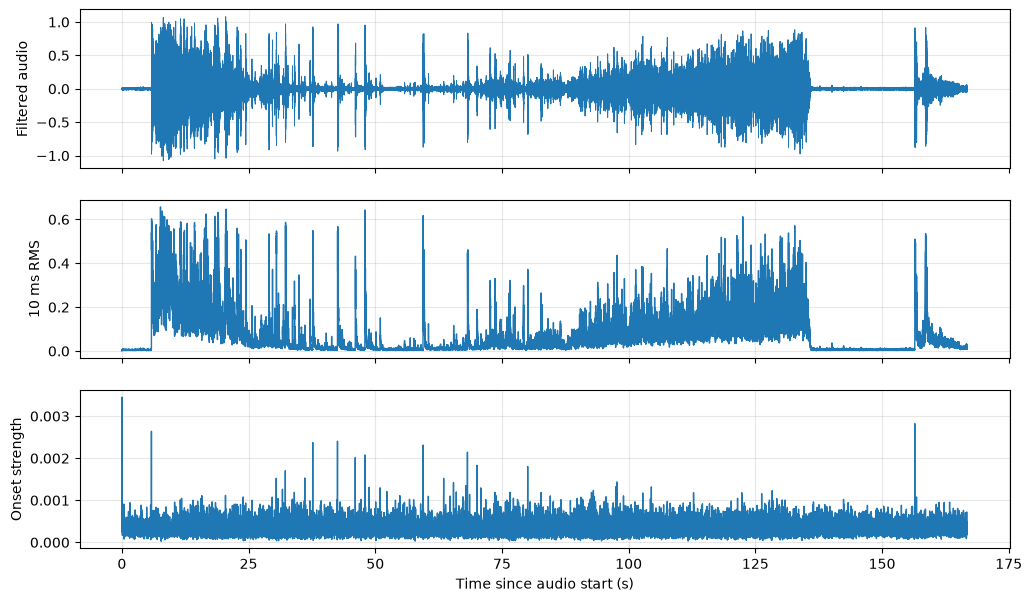

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

tr = st_audio[0].copy()
tr.detrend("demean")

# Emphasize perceived impulsive "crack"
tr.filter("bandpass", freqmin=100, freqmax=1000, corners=4, zerophase=True)

x = tr.data.astype(float)
fs = tr.stats.sampling_rate
t = tr.times()

# short-time RMS envelope, 10 ms
win = max(1, int(0.010 * fs))
rms = np.sqrt(np.convolve(x**2, np.ones(win)/win, mode="same"))

# onset strength: positive changes in log RMS
logrms = np.log10(rms + 1e-8)
onset = np.maximum(np.gradient(logrms), 0)
onset_smooth = gaussian_filter1d(onset, sigma=int(0.005 * fs))

fig, ax = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

ax[0].plot(t, x, lw=0.7)
ax[0].set_ylabel("Filtered audio")

ax[1].plot(t, rms, lw=1)
ax[1].set_ylabel("10 ms RMS")

ax[2].plot(t, onset_smooth, lw=1)
ax[2].set_ylabel("Onset strength")
ax[2].set_xlabel("Time since audio start (s)")

for a in ax:
    a.grid(True, alpha=0.3)

plt.show()

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

tr = st_audio[0].copy()
tr.detrend("demean")

# Emphasize audible blast transients
tr.filter("bandpass", freqmin=1000, freqmax=3000, corners=4, zerophase=True)

x = tr.data.astype(float)
fs = tr.stats.sampling_rate
t = tr.times()

# 10 ms RMS envelope
win = int(0.010 * fs)
rms = np.sqrt(np.convolve(x**2, np.ones(win) / win, mode="same"))

# Smooth slightly, e.g. 20 ms
rms_smooth = gaussian_filter1d(rms, sigma=int(0.020 * fs))

# Detection threshold: robust noise estimate from first 0.3 s, adjust as needed
noise_mask = t < 0.3
mu = np.median(rms_smooth[noise_mask])
mad = np.median(np.abs(rms_smooth[noise_mask] - mu))
sigma = 1.4826 * mad

threshold = mu + 8 * sigma

# Detect peaks separated by at least 0.15 s
peaks, props = find_peaks(
    rms_smooth,
    height=threshold,
    distance=int(0.15 * fs),
    prominence=3 * sigma,
)

print("Detected audio peaks:")
for p in peaks:
    print(f"{t[p]:7.3f} s   RMS={rms_smooth[p]:.4f}")


Detected audio peaks:
  1.613 s   RMS=0.0033
  2.360 s   RMS=0.0036
  2.712 s   RMS=0.0030
  3.101 s   RMS=0.0038
  3.394 s   RMS=0.0032
  3.981 s   RMS=0.0033
  4.146 s   RMS=0.0086
  4.305 s   RMS=0.0357
  5.854 s   RMS=0.0677
  6.048 s   RMS=0.0148
  6.242 s   RMS=0.0079
  6.761 s   RMS=0.0131
  7.002 s   RMS=0.0063
  7.302 s   RMS=0.0096
  7.591 s   RMS=0.0116
  7.934 s   RMS=0.0250
  8.168 s   RMS=0.0230
  8.411 s   RMS=0.0534
  9.018 s   RMS=0.0349
  9.274 s   RMS=0.0674
  9.486 s   RMS=0.1558
  9.737 s   RMS=0.1009
  9.996 s   RMS=0.0881
 10.448 s   RMS=0.0502
 10.607 s   RMS=0.0448
 10.987 s   RMS=0.0437
 11.344 s   RMS=0.0208
 11.555 s   RMS=0.0808
 11.953 s   RMS=0.0127
 12.260 s   RMS=0.0560
 12.425 s   RMS=0.0130
 12.580 s   RMS=0.0107
 12.863 s   RMS=0.0117
 13.043 s   RMS=0.0092
 13.670 s   RMS=0.0106
 13.883 s   RMS=0.0103
 14.101 s   RMS=0.0098
 14.315 s   RMS=0.0177
 14.575 s   RMS=0.0089
 14.740 s   RMS=0.0103
 15.104 s   RMS=0.0072
 15.372 s   RMS=0.0067
 15.620 s   

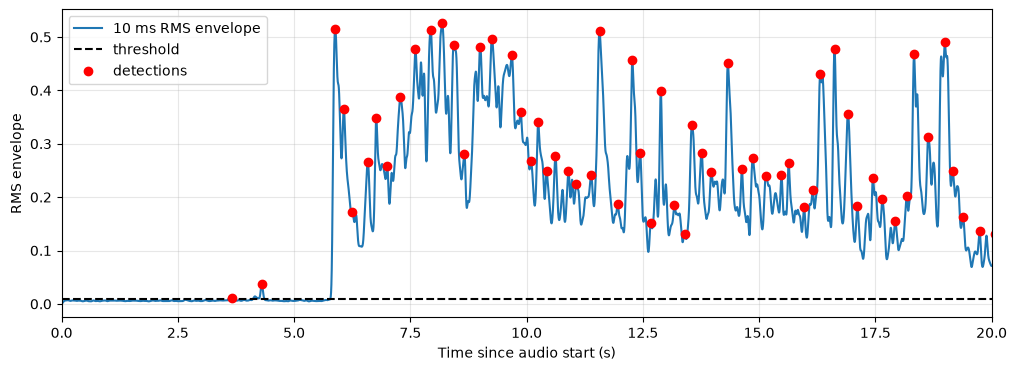

In [27]:

plt.figure(figsize=(12, 4))
plt.plot(t, rms_smooth, label="10 ms RMS envelope")
plt.axhline(threshold, color="k", ls="--", label="threshold")
plt.plot(t[peaks], rms_smooth[peaks], "ro", label="detections")
plt.xlabel("Time since audio start (s)")
plt.ylabel("RMS envelope")
plt.xlim(0, 20)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Triggers:
  4.140 –   4.169 s
  4.288 –   4.325 s
  5.835 –   5.868 s
  6.740 –   6.788 s
  7.235 –   7.247 s
  7.306 –   7.320 s
  7.553 –   7.573 s
  7.594 –   7.606 s
  7.898 –   7.961 s
  8.152 –   8.190 s
  8.396 –   8.423 s
  8.910 –   8.933 s
  9.010 –   9.038 s
  9.233 –   9.290 s
  9.400 –   9.421 s
 11.527 –  11.586 s
 12.247 –  12.279 s
 14.305 –  14.338 s
 15.786 –  15.801 s
 16.295 –  16.333 s
 16.369 –  16.378 s
 16.597 –  16.652 s
 17.006 –  17.050 s
 18.303 –  18.332 s
 18.882 –  18.969 s
 20.444 –  20.480 s
 20.552 –  20.559 s
 22.729 –  22.765 s
 22.948 –  22.967 s
 24.434 –  24.482 s


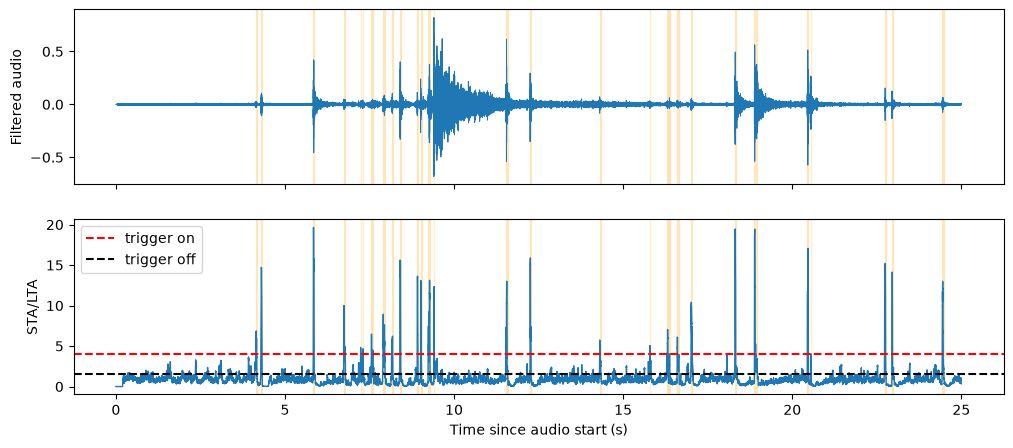

In [32]:
from obspy.signal.trigger import classic_sta_lta, trigger_onset
import matplotlib.pyplot as plt
import numpy as np

tr = st_audio[0].copy().trim(endtime=st_audio[0].stats.starttime + 25)  # analyze first 25 seconds
tr.detrend("demean")
tr.filter("bandpass", freqmin=1000, freqmax=3000, corners=4, zerophase=True)

x = tr.data.astype(float)
fs = tr.stats.sampling_rate
t = tr.times()

# STA/LTA windows
sta = int(0.01 * fs)   # 20 ms
lta = int(0.2 * fs)    # 500 ms

cft = classic_sta_lta(x, sta, lta)

# Trigger thresholds
on = 4.0
off = 1.5

trigs = trigger_onset(cft, on, off)

print("Triggers:")
for i1, i2 in trigs:
    print(f"{t[i1]:7.3f} – {t[i2]:7.3f} s")

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

ax[0].plot(t, x, lw=0.7)
ax[0].set_ylabel("Filtered audio")

ax[1].plot(t, cft, lw=1)
ax[1].axhline(on, color="r", ls="--", label="trigger on")
ax[1].axhline(off, color="k", ls="--", label="trigger off")

for i1, i2 in trigs:
    ax[0].axvspan(t[i1], t[i2], color="orange", alpha=0.2)
    ax[1].axvspan(t[i1], t[i2], color="orange", alpha=0.2)

ax[1].set_ylabel("STA/LTA")
ax[1].set_xlabel("Time since audio start (s)")
ax[1].legend()
plt.show()

Triggers:
  4.130 –   4.216 s
  4.285 –   4.368 s
  5.829 –   5.981 s
  7.906 –   8.018 s
  8.167 –   8.232 s
  8.398 –   8.504 s
  9.021 –   9.072 s
  9.263 –   9.360 s
  9.398 –   9.701 s
 11.550 –  11.625 s
 12.260 –  12.317 s
 14.322 –  14.380 s
 16.642 –  16.685 s
 17.017 –  17.096 s
 18.298 –  18.486 s
 18.885 –  19.026 s
 20.448 –  20.608 s
 22.732 –  22.816 s
 22.950 –  23.049 s
 24.436 –  24.547 s
 27.531 –  27.614 s
 28.987 –  29.112 s
 29.765 –  29.824 s
 30.491 –  30.565 s
 32.265 –  32.400 s
 37.658 –  37.751 s
 42.541 –  42.669 s
 46.058 –  46.173 s
 47.947 –  48.087 s
 59.437 –  59.694 s
 68.182 –  68.311 s
 70.074 –  70.186 s
 72.661 –  72.766 s
 74.830 –  75.044 s
 79.254 –  79.324 s
 82.923 –  82.974 s
 87.086 –  87.118 s
 87.417 –  87.610 s
 87.643 –  87.706 s
 90.362 –  90.426 s
 90.589 –  90.773 s
 90.949 –  91.009 s
 95.413 –  95.487 s
 95.753 –  95.955 s
 96.006 –  96.060 s
 99.467 –  99.524 s
101.375 – 101.454 s
101.933 – 101.986 s
103.705 – 103.756 s
103.950 – 

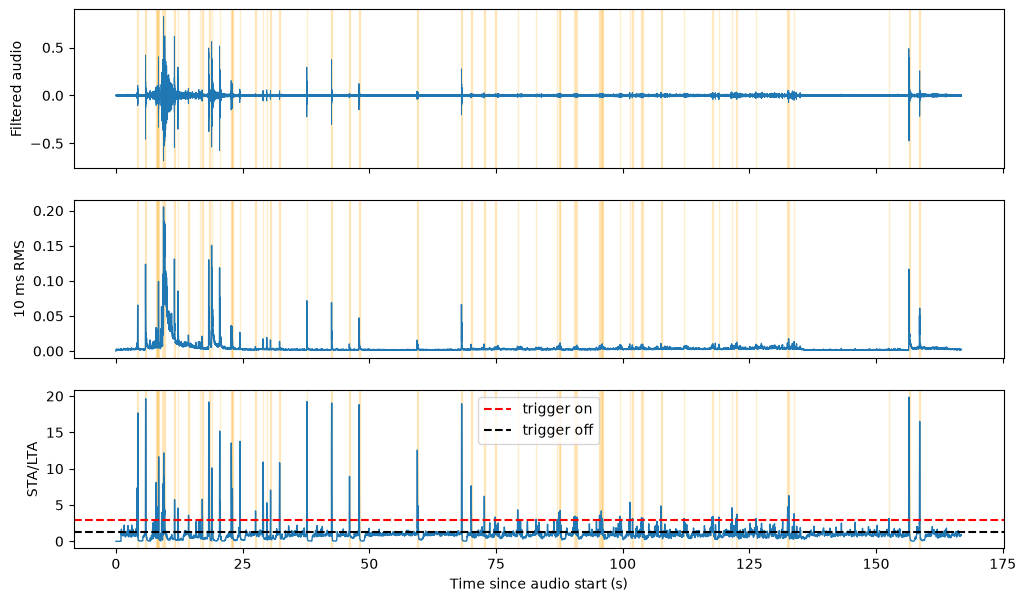

65  triggers detected


In [ ]:
from obspy.signal.trigger import classic_sta_lta, trigger_onset
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

tr = st_audio[0].copy()#.trim(endtime=st_audio[0].stats.starttime + 25)  # analyze first 25 seconds
tr.detrend("demean")
tr.filter("bandpass", freqmin=1000, freqmax=3000, corners=4, zerophase=True)

x = tr.data.astype(float)
fs = tr.stats.sampling_rate
t = tr.times()

# 10 ms RMS envelope
win = int(0.010 * fs)
rms = np.sqrt(np.convolve(x**2, np.ones(win)/win, mode="same"))

# Optional smoothing
rms = gaussian_filter1d(rms, sigma=int(0.005 * fs))

# Treat RMS as the signal for STA/LTA
sta = int(0.05 * fs)   # 50 ms
lta = int(1.0 * fs)    # 1 s

cft = classic_sta_lta(rms.astype(np.float64), sta, lta)

on = 3.0
off = 1.3
trigs = trigger_onset(cft, on, off)

print("Triggers:")
for i1, i2 in trigs:
    print(f"{t[i1]:7.3f} – {t[i2]:7.3f} s")

fig, ax = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

ax[0].plot(t, x, lw=0.7)
ax[0].set_ylabel("Filtered audio")

ax[1].plot(t, rms, lw=1)
ax[1].set_ylabel("10 ms RMS")

ax[2].plot(t, cft, lw=1)
ax[2].axhline(on, color="r", ls="--", label="trigger on")
ax[2].axhline(off, color="k", ls="--", label="trigger off")
ax[2].set_ylabel("STA/LTA")
ax[2].set_xlabel("Time since audio start (s)")
ax[2].legend()

for i1, i2 in trigs:
    for a in ax:
        a.axvspan(t[i1], t[i2], color="orange", alpha=0.2)

plt.show()


In [43]:

print(len(trigs), " triggers detected")
print(tr.stats)
print(tr)
print(tr.stats.endtime - tr.stats.starttime + tr.stats.delta)

65  triggers detected
         network: YT
         station: SYNC
        location: 
         channel: AUD
       starttime: 2016-09-01T13:07:10.000000Z
         endtime: 2016-09-01T13:09:56.827755Z
   sampling_rate: 44100.0
           delta: 2.2675736961451248e-05
            npts: 7357105
           calib: 1.0
      processing: ["ObsPy 1.5.0: detrend(options={}::type='demean')", "ObsPy 1.5.0: filter(args=()::options={'freqmin': 1000, 'freqmax': 3000, 'corners': 4, 'zerophase': True}::type='bandpass')"]
YT.SYNC..AUD | 2016-09-01T13:07:10.000000Z - 2016-09-01T13:09:56.827755Z | 44100.0 Hz, 7357105 samples
166.82777767573697
